In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import(accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)

In [ ]:
ts=pd.read_csv('/content/twitter_sentiment.csv')

In [ ]:
ts.head()

,Topic,Sentiment,TweetId,TweetDate,TweetText
0,apple,positive,126415614616154112,Tue Oct 18 21:53:25 +0000 2011,Now all @Apple has to do is get swype on the i...
1,apple,positive,126404574230740992,Tue Oct 18 21:09:33 +0000 2011,@Apple will be adding more carrier support to ...
2,apple,positive,126402758403305474,Tue Oct 18 21:02:20 +0000 2011,Hilarious @youtube video - guy does a duet wit...
3,apple,positive,126397179614068736,Tue Oct 18 20:40:10 +0000 2011,@RIM you made it too easy for me to switch to ...
4,apple,positive,126395626979196928,Tue Oct 18 20:34:00 +0000 2011,I just realized that the reason I got into twi...


In [ ]:
ts.shape

(5113, 5)

In [ ]:
# Step 3: Explore and clean

print("Sentiment distribution:")
print(ts['Sentiment'].value_counts())

# Keep only Positive and Negative tweets for binary classification
ts = ts[ts['Sentiment'].isin(['positive', 'negative'])].copy()

# Rename columns for convenience
ts = ts.rename(columns={'TweetText': 'tweet', 'Sentiment': 'sentiment'})

# Convert labels to numbers
ts['label'] = ts['sentiment'].map({'positive': 1, 'negative': 0})

print("\nAfter filtering (only positive & negative):")
print(ts['sentiment'].value_counts())
print("\nShape:", ts.shape)
display(ts.head())

Sentiment distribution:
Sentiment
neutral       2333
irrelevant    1689
negative       572
positive       519
Name: count, dtype: int64

After filtering (only positive & negative):
sentiment
negative    572
positive    519
Name: count, dtype: int64

Shape: (1091, 6)


,Topic,sentiment,TweetId,TweetDate,tweet,label
0,apple,positive,126415614616154112,Tue Oct 18 21:53:25 +0000 2011,Now all @Apple has to do is get swype on the i...,1
1,apple,positive,126404574230740992,Tue Oct 18 21:09:33 +0000 2011,@Apple will be adding more carrier support to ...,1
2,apple,positive,126402758403305474,Tue Oct 18 21:02:20 +0000 2011,Hilarious @youtube video - guy does a duet wit...,1
3,apple,positive,126397179614068736,Tue Oct 18 20:40:10 +0000 2011,@RIM you made it too easy for me to switch to ...,1
4,apple,positive,126395626979196928,Tue Oct 18 20:34:00 +0000 2011,I just realized that the reason I got into twi...,1


In [ ]:
ts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1091 entries, 0 to 3951
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Topic      1091 non-null   object
 1   sentiment  1091 non-null   object
 2   TweetId    1091 non-null   int64 
 3   TweetDate  1091 non-null   object
 4   tweet      1091 non-null   object
 5   label      1091 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 59.7+ KB


In [ ]:
ts.isnull().sum()

,0
Topic,0
sentiment,0
TweetId,0
TweetDate,0
tweet,0
label,0


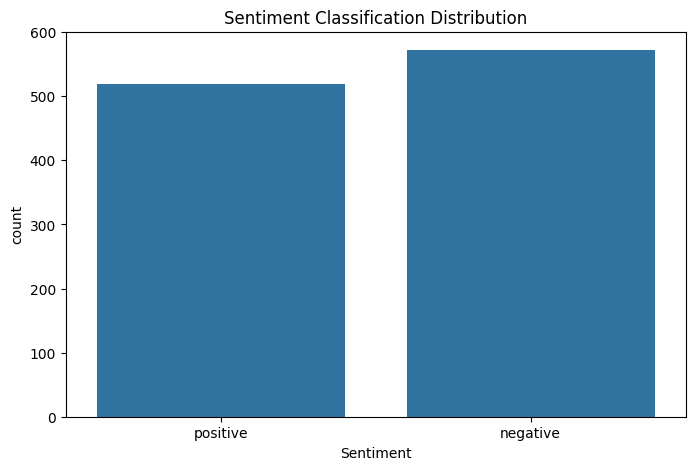

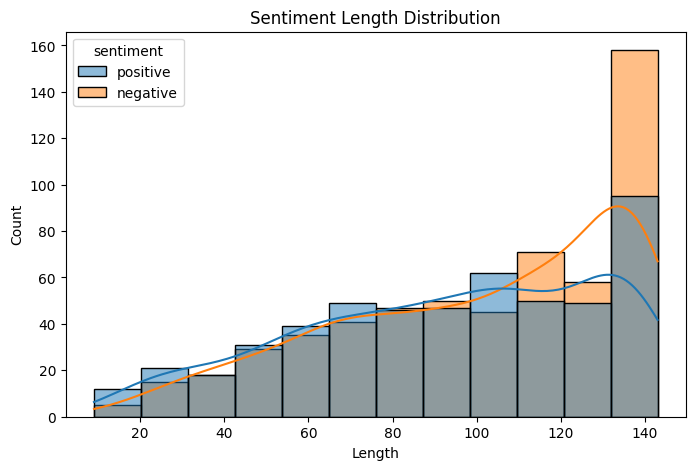

Average Length positive messages: 92.97
Average Length negative messages: 100.87


In [ ]:
#classification
plt.figure(figsize=(8,5))
sns.countplot(x='sentiment',data=ts)
plt.title('Sentiment Classification Distribution')
plt.xlabel('Sentiment')
plt.show()

# Calculate length of TweetText and add as a new column
ts['Length'] = ts['tweet'].apply(len)

#Review length analysis (positive vs negative)
plt.figure(figsize=(8,5))
sns.histplot(x='Length',data=ts,hue='sentiment',kde=True)
plt.title('Sentiment Length Distribution')
plt.show()

print('Average Length positive messages:' , round(ts[ts['sentiment']=='positive']['Length'].mean(),2))
print('Average Length negative messages:' , round(ts[ts['sentiment']=='negative']['Length'].mean(),2))

In [ ]:
ts.columns.tolist()

['Topic', 'sentiment', 'TweetId', 'TweetDate', 'tweet', 'label']

In [ ]:
x=ts['tweet']
y=ts['sentiment']

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

print('Training Sample:',len(x_train))
print('Testing Sample:',len(x_test))

Training Sample: 872
Testing Sample: 219


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
x_train_cv= vectorizer.fit_transform(x_train)
x_test_cv= vectorizer.transform(x_test)

print("Vocabulary size:", len(vectorizer.get_feature_names_out()))
print("Training features shape:", x_train_cv.shape)
print("Testing features shape :", x_test_cv.shape)

Vocabulary size: 2935
Training features shape: (872, 2935)
Testing features shape : (219, 2935)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
model= MultinomialNB()
model.fit(x_train_cv,y_train)

MultinomialNB()

In [ ]:
y_pred=model.predict(x_test_cv)
print('First 10 Actual label:',y_test.values[:10])
print('First 10 prediction label:', y_pred[:10])

First 10 Actual label: ['negative' 'positive' 'negative' 'negative' 'negative' 'negative'
 'positive' 'positive' 'negative' 'negative']
First 10 prediction label: ['positive' 'positive' 'negative' 'positive' 'negative' 'negative'
 'positive' 'positive' 'positive' 'positive']



Confusion Matrix:
[[97 18]
 [26 78]]


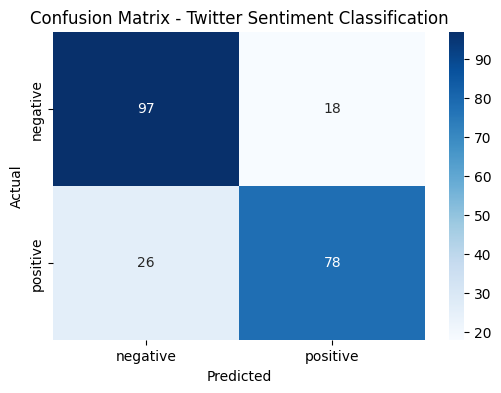

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[ 'negative', 'positive'],
            yticklabels=[ 'negative', 'positive'])
plt.title("Confusion Matrix - Twitter Sentiment Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import string # Import string module for punctuation

def clean_text(text):
    text = text.lower() # Convert to lowercase
    text = ''.join([char for char in text if char not in string.punctuation]) # Remove punctuation
    return text

new_tweets = [
    "I absolutely love this new phone! The camera is amazing and battery lasts forever.",
    "This is the worst service I have ever experienced. Completely disappointed and angry.",
    "Just had a normal day at work, nothing special happening.",
    "Wow! What a fantastic performance by the team today! So proud of them!",
    "The product broke after two days. Total waste of money. Never buying again."
]

# Clean the new tweets the same way
new_tweets_clean = [clean_text(t) for t in new_tweets]

# Vectorize
new_tweets_vec = vectorizer.transform(new_tweets_clean)

# Predict using MultinomialNB model
predictions = model.predict(new_tweets_vec)
probabilities = model.predict_proba(new_tweets_vec)

print("Predictions on New Tweets:\n")
for tweet, pred, prob in zip(new_tweets, predictions, probabilities):
    # The 'y' labels are 'negative' and 'positive' (strings) from training
    # model.classes_ will be ['negative', 'positive']
    if pred == 'positive':
        confidence = prob[1] * 100 # prob[1] corresponds to 'positive'
    else:
        confidence = prob[0] * 100 # prob[0] corresponds to 'negative'
    print(f"Tweet: {tweet}")
    print(f"→ Prediction: {pred} (Confidence: {confidence:.2f}%) ") # Corrected f-string closing quote
    print("-" * 90)

Predictions on New Tweets:

Tweet: I absolutely love this new phone! The camera is amazing and battery lasts forever.
→ Prediction: positive (Confidence: 99.37%) 
------------------------------------------------------------------------------------------
Tweet: This is the worst service I have ever experienced. Completely disappointed and angry.
→ Prediction: negative (Confidence: 85.41%) 
------------------------------------------------------------------------------------------
Tweet: Just had a normal day at work, nothing special happening.
→ Prediction: negative (Confidence: 88.43%) 
------------------------------------------------------------------------------------------
Tweet: Wow! What a fantastic performance by the team today! So proud of them!
→ Prediction: positive (Confidence: 96.84%) 
------------------------------------------------------------------------------------------
Tweet: The product broke after two days. Total waste of money. Never buying again.
→ Prediction: negat